In [4]:
import sys
print(sys.executable)

C:\Users\enric\tangram\.venv\Scripts\python.exe


In [ ]:
%cd ..
import mytangram as tg

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

C:\Users\enric\tangram\.venv\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
!cd

C:\Users\enric\tangram\MyNotebooks


Before reading Drive files it is necessary to prompt Windows to load the full file in the local machine (stream mode). One can do this manually by opening the local Drive disk on the file explorer or automatically exploiting a python script to load metadata:

In [10]:
### Does not work --- skip

import os

# Touch the file to prompt Windows to load it (may trigger Drive to stream it)
try:
    os.stat(r"H:/Il mio Drive/dati_per_enrico.lnk/counts100k_norm_wo_raw.h5ad")
    print("File metadata accessed.")
except FileNotFoundError:
    print("File not accessible yet.")

File not accessible yet.


Retrieve true file path in drive through link:

In [2]:
!uv pip install winshell

Using Python 3.10.17 environment at: C:\Users\enric\tangram\.venv
Audited 1 package in 67ms


In [3]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")


Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


In [5]:
%cd H:/Il mio Drive/

H:\Il mio Drive


C:\Users\enric\tangram\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
!dir /a

# Training genes set
The purpose of this notebook is to investgate how different training genes sets affect the mapping results, exploring the relevancy of genes' expression levels in both scRNA data and spatial data.

# SC Data

## Data loading
The scRNA-seq dataset has been downsampled to 100k cells exaclty, underwent some prior cell fitering and counts normalization. Here we load the float32 filtered version obtianed in the cells selection notebook.

In [ ]:
#adata_sc = sq.datasets.sc_mouse_cortex()
adata_sc = sc.read_h5ad('H:/Il mio Drive/data_tangram/counts100k_light_filt.h5ad')
adata_sc

In [5]:
adata_sc.obs.head()

,nUMI,nGene,dataset,QC,cluster,Allen.cluster_id,Allen.cluster_label,Allen.cluster_color,Allen.class_label,Allen.subclass_label,comb.QC
pBICCNsMMrMOpRPiF006d190314_CTCATCGTCCGCTAGG,14213,4810,FEMALE,PassQC,Ex3_5,66.0,L6 CT Cpa6,#338C5E,Glutamatergic,L6 CT,PassQC
pBICCNsMMrMOpRMiF004d190318_TCCGAAACAAATCAAG,2333,1514,FEMALE,PassQC,Fibro1_5,98.0,VLMC_3,#476655,Non-Neuronal,VLMC,PassQC
pBICCNsMMrMOpRPiM008d190320_GACACGCGTTCAGCGC,2253,1319,MALE,PassQC,Oligo_21,90.0,Oligo Opalin_4,#474662,Non-Neuronal,Oligo,PassQC
pBICCNsMMrMOpRAiM008d190320_TTCGGTCGTGTATTCG,1440,1078,MALE,PassQC,Micro_0,113.0,Macrophage_2,#476655,Non-Neuronal,Macrophage,PassQC
pBICCNsMMrMOpRMiF007d190314_TATTCCAGTCCAACGC,10699,3897,FEMALE,PassQC,Ex5_2,64.0,L5/6 NP_3,#47867A,Glutamatergic,L5/6 NP,PassQC


In [6]:
adata_sc.var.head()

,gene_ids,feature_types
Xkr4,0,Gene Expression
Gm1992,1,Gene Expression
Gm37381,2,Gene Expression
Rp1,3,Gene Expression
Sox17,4,Gene Expression


In [5]:
print(f"Min: {adata_sc.X.min()}, " + f"Max: {adata_sc.X.max()}")
adata_sc.X

Min: 0.0, Max: 11.830928802490234


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 309485087 stored elements and shape (77337, 31053)>

In [6]:
adata_sc.obs.keys()

Index(['nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id',
       'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label',
       'Allen.subclass_label', 'comb.QC'],
      dtype='object')

In [7]:
adata_sc.var.keys()

Index(['gene_ids', 'feature_types'], dtype='object')

### HVGs

Here we identfy the subset of highly variable genes with Scanpy's built-in preprocessing function:

<dt><strong>flavor</strong> <span class="classifier"><span class="sphinx_autodoc_typehints-type"><a class="reference external" href="https://docs.python.org/3/library/typing.html#typing.Literal" title="(in Python v3.13)"><code class="xref py py-data docutils literal notranslate"><span class="pre">Literal</span></code></a>[<code class="docutils literal notranslate"><span class="pre">'seurat'</span></code>, <code class="docutils literal notranslate"><span class="pre">'cell_ranger'</span></code>, <code class="docutils literal notranslate"><span class="pre">'seurat_v3'</span></code>, <code class="docutils literal notranslate"><span class="pre">'seurat_v3_paper'</span></code>]</span> (default: <code class="docutils literal notranslate"><span class="pre">'seurat'</span></code>)</span></dt></dt><dd><p>Choose the flavor for identifying highly variable genes. For the dispersion
based methods in their default workflows, Seurat passes the cutoffs whereas
Cell Ranger passes <code class="docutils literal notranslate"><span class="pre">n_top_genes</span></code>.</p>
</dd>

<p>Depending on <code class="docutils literal notranslate"><span class="pre">flavor</span></code>, this reproduces the R-implementations of Seurat
<span id="id2">[<a class="reference internal" href="../references.html#id54" title="Rahul Satija, Jeffrey A Farrell, David Gennert, Alexander F Schier, and Aviv Regev. Spatial reconstruction of single-cell gene expression data. Nature Biotechnology, 33(5):495–502, apr 2015. URL: https://doi.org/10.1038/nbt.3192, doi:10.1038/nbt.3192.">Satija <em>et al.</em>, 2015</a>]</span>, Cell Ranger <span id="id3">[<a class="reference internal" href="../references.html#id76" title="Grace X. Y. Zheng, Jessica M. Terry, Phillip Belgrader, Paul Ryvkin, Zachary W. Bent, Ryan Wilson, Solongo B. Ziraldo, Tobias D. Wheeler, Geoff P. McDermott, Junjie Zhu, Mark T. Gregory, Joe Shuga, Luz Montesclaros, Jason G. Underwood, Donald A. Masquelier, Stefanie Y. Nishimura, Michael Schnall-Levin, Paul W. Wyatt, Christopher M. Hindson, Rajiv Bharadwaj, Alexander Wong, Kevin D. Ness, Lan W. Beppu, H. Joachim Deeg, Christopher McFarland, Keith R. Loeb, William J. Valente, Nolan G. Ericson, Emily A. Stevens, Jerald P. Radich, Tarjei S. Mikkelsen, Benjamin J. Hindson, and Jason H. Bielas. Massively parallel digital transcriptional profiling of single cells. Nature Communications, jan 2017. URL: https://doi.org/10.1038/ncomms14049, doi:10.1038/ncomms14049.">Zheng <em>et al.</em>, 2017</a>]</span>, and Seurat v3 <span id="id4">[<a class="reference internal" href="../references.html#id61" title="Tim Stuart, Andrew Butler, Paul Hoffman, Christoph Hafemeister, Efthymia Papalexi, William M. Mauck, Yuhan Hao, Marlon Stoeckius, Peter Smibert, and Rahul Satija. Comprehensive integration of single-cell data. Cell, 177(7):1888–1902.e21, jun 2019. URL: https://doi.org/10.1016/j.cell.2019.05.031, doi:10.1016/j.cell.2019.05.031.">Stuart <em>et al.</em>, 2019</a>]</span>.</p>
<p><code class="docutils literal notranslate"><span class="pre">'seurat_v3'</span></code>/<code class="docutils literal notranslate"><span class="pre">'seurat_v3_paper'</span></code> requires <code class="docutils literal notranslate"><span class="pre">scikit-misc</span></code> package. If you plan to use this flavor, consider
installing <code class="docutils literal notranslate"><span class="pre">scanpy</span></code> with this optional dependency: <code class="docutils literal notranslate"><span class="pre">scanpy[skmisc]</span></code>.</p>
<p>For the dispersion-based methods (<code class="docutils literal notranslate"><span class="pre">flavor='seurat'</span></code> <span id="id5">Satija <em>et al.</em> [<a class="reference internal" href="../references.html#id54" title="Rahul Satija, Jeffrey A Farrell, David Gennert, Alexander F Schier, and Aviv Regev. Spatial reconstruction of single-cell gene expression data. Nature Biotechnology, 33(5):495–502, apr 2015. URL: https://doi.org/10.1038/nbt.3192, doi:10.1038/nbt.3192.">2015</a>]</span> and
<code class="docutils literal notranslate"><span class="pre">flavor='cell_ranger'</span></code> <span id="id6">Zheng <em>et al.</em> [<a class="reference internal" href="../references.html#id76" title="Grace X. Y. Zheng, Jessica M. Terry, Phillip Belgrader, Paul Ryvkin, Zachary W. Bent, Ryan Wilson, Solongo B. Ziraldo, Tobias D. Wheeler, Geoff P. McDermott, Junjie Zhu, Mark T. Gregory, Joe Shuga, Luz Montesclaros, Jason G. Underwood, Donald A. Masquelier, Stefanie Y. Nishimura, Michael Schnall-Levin, Paul W. Wyatt, Christopher M. Hindson, Rajiv Bharadwaj, Alexander Wong, Kevin D. Ness, Lan W. Beppu, H. Joachim Deeg, Christopher McFarland, Keith R. Loeb, William J. Valente, Nolan G. Ericson, Emily A. Stevens, Jerald P. Radich, Tarjei S. Mikkelsen, Benjamin J. Hindson, and Jason H. Bielas. Massively parallel digital transcriptional profiling of single cells. Nature Communications, jan 2017. URL: https://doi.org/10.1038/ncomms14049, doi:10.1038/ncomms14049.">2017</a>]</span>), the normalized dispersion is obtained
by scaling with the mean and standard deviation of the dispersions for genes
falling into a given bin for mean expression of genes. This means that for each
bin of mean expression, highly variable genes are selected.</p>
<p>For <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3'</span></code>/<code class="docutils literal notranslate"><span class="pre">'seurat_v3_paper'</span></code> <span id="id7">[<a class="reference internal" href="../references.html#id61" title="Tim Stuart, Andrew Butler, Paul Hoffman, Christoph Hafemeister, Efthymia Papalexi, William M. Mauck, Yuhan Hao, Marlon Stoeckius, Peter Smibert, and Rahul Satija. Comprehensive integration of single-cell data. Cell, 177(7):1888–1902.e21, jun 2019. URL: https://doi.org/10.1016/j.cell.2019.05.031, doi:10.1016/j.cell.2019.05.031.">Stuart <em>et al.</em>, 2019</a>]</span>, a normalized variance for each gene
is computed. First, the data are standardized (i.e., z-score normalization
per feature) with a regularized standard deviation. Next, the normalized variance
is computed as the variance of each gene after the transformation. Genes are ranked
by the normalized variance.
Only if <code class="docutils literal notranslate"><span class="pre">batch_key</span></code> is not <code class="docutils literal notranslate"><span class="pre">None</span></code>, the two flavors differ: For <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3'</span></code>, genes are first sorted by the median (across batches) rank, with ties broken by the number of batches a gene is a HVG.
For <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3_paper'</span></code>, genes are first sorted by the number of batches a gene is a HVG, with ties broken by the median (across batches) rank.</p>
<p>The following may help when comparing to Seurat’s naming:
If <code class="docutils literal notranslate"><span class="pre">batch_key=None</span></code> and <code class="docutils literal notranslate"><span class="pre">flavor='seurat'</span></code>, this mimics Seurat’s <code class="docutils literal notranslate"><span class="pre">FindVariableFeatures(…,</span> <span class="pre">method='mean.var.plot')</span></code>.
If <code class="docutils literal notranslate"><span class="pre">batch_key=None</span></code> and <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3'</span></code>/<code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3_paper'</span></code>, this mimics Seurat’s <code class="docutils literal notranslate"><span class="pre">FindVariableFeatures(...,</span> <span class="pre">method='vst')</span></code>.
If <code class="docutils literal notranslate"><span class="pre">batch_key</span></code> is not <code class="docutils literal notranslate"><span class="pre">None</span></code> and <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3_paper'</span></code>, this mimics Seurat’s <code class="docutils literal notranslate"><span class="pre">SelectIntegrationFeatures</span></code>.</p>
<p>See also <code class="docutils literal notranslate"><span class="pre">scanpy.experimental.pp._highly_variable_genes</span></code> for additional flavors
(e.g. Pearson residuals).</p>

In [8]:
# Solve dependency issue for sc.pp.highly_variable_genes()
!uv pip install scikit-misc  # only for mode='seurat_v3'

Using Python 3.10.17 environment at: C:\Users\enric\tangram\.venv
Audited 1 package in 92ms


In [5]:
# mode='seurat_v3' requires raw counts, use 'seurat' with log-transformed
sc.pp.highly_variable_genes(adata_sc, n_top_genes=4000, flavor='seurat')

In [11]:
adata_sc.uns['hvg']

{'flavor': 'seurat'}

The highly variables genes set is available as a mask on the variables of the AnnData object:

In [8]:
adata_sc.var['highly_variable']

Xkr4              False
Gm1992            False
Gm37381           False
Rp1               False
Sox17              True
                  ...  
AC168977.1        False
AC149090.1        False
CAAA01118383.1    False
Vmn2r122          False
CAAA01147332.1    False
Name: highly_variable, Length: 31053, dtype: bool

with a total of hvg equal to:

In [13]:
sum(adata_sc.var['highly_variable'])

4000

## Sparsity

Now, we count the number of all-zero genes:

In [9]:
all_zero_count = sum(np.array(adata_sc.X.sum(axis=0)).flatten() == 0)

In [10]:
print('All zeros genes:', all_zero_count)

All zeros genes: 3741


Then we can check the sparsity level of the counts matrix by accesing the 

In [11]:
sparsity = 1 - adata_sc.X.nnz / (adata_sc.n_obs * adata_sc.n_vars)  
# equivalent values
# adata_sc.X.size
# adata_sc.X.shape[0]
# adata_sc.X.shape[1]

In [12]:
print('Sparsity level of sc data:', '{} %'.format(round(sparsity, 3)*100))

Sparsity level of sc data: 87.1 %


Ultimately, we are interested in measuring the sparsity level of each gene, that we can also annotated on the anndata object:

In [ ]:
# Compute the sparsity of each gene (column) in the count matrix
sparsity_sc = np.mean(adata_sc.X == 0, axis=0)

# Add sparsity information to the 'var' DataFrame
adata.var['sparsity'] = sparsity_sc

From the annotation we can take a look at the histogram:

In [ ]:
# Plot histogram of gene sparsity
plt.figure(figsize=(6,4))
plt.hist(sparsity_sc, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('SC Gene Sparsity')
plt.ylabel('Frequency')
plt.title('Distribution of Gene Sparsity')
plt.show()

This procedure encounters an error due to memory usage, thus it is not carried out. The same step is applied later on a dataset cropped on training genes only (see Genes Interestcion Analysis).

## SPAPROS: SPatial PRObe Selection
**NOTE**: reduce dataset size with cell selction before running (space constraint).


**SPARPos** is a method for selecting a subset of genes (probes) from single-cell RNA-seq data to be used in spatial transcriptomics experiments. Its main goal is to identify genes that are both **informative of cell types** and **spatially informative**, allowing spatial assays to capture key biological variation using a limited number of measured genes.

**How it works:**
- SPARPos takes single-cell RNA-seq data as input.
- It evaluates genes based on their ability to distinguish cell types or states.
- It prioritizes genes that are likely to show **spatially distinct expression patterns** when measured in a tissue section.
- The output is a ranked list of genes suitable for targeted spatial profiling.

**Typical use case:**
- Designing **targeted spatial transcriptomics panels**, where only a limited number of genes can be measured due to experimental constraints.
- Reducing cost and complexity while retaining the most biologically informative signals for downstream spatial mapping and deconvolution.

In the Tangram Refinements paper it is suggested as a possible way of selecting genes for training. 

Here we explore its application on the given dataset.

In [6]:
import spapros as sp
print(f"spapros=={sp.__version__}")

spapros==0.1.5


### Pre-processing
To run, Spapros requires:
* log-transformed count with no gene z-score (ok)
* pre-selected hvgs (ok)
* pre-existent UMAP embedding (missing)
* cell type labels (ok)

Thus we run scanpy UMAP with default settings (proper tuning can be experimented on):

In [7]:
# UMAP
sc.pp.neighbors(adata=adata_sc, n_neighbors=15, knn=True, method='umap', random_state=0,copy=False)  # required for umap
sc.tl.umap(adata=adata_sc, n_components=2, random_state=42, copy=False)
adata_sc.uns['umap']
# auto-computes default pca

C:\Users\enric\tangram\.venv\lib\site-packages\scanpy\tools\_utils.py:40: UserWarning: You’re trying to run this on 31053 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


{'params': {'a': np.float64(0.5830300202072974),
  'b': np.float64(1.3341669926670465),
  'random_state': 42}}

which we can quickly visualize, coloring by a label of choice. Here we color by both cell class and subclass side by side to attest the difference in groups size and granularity:

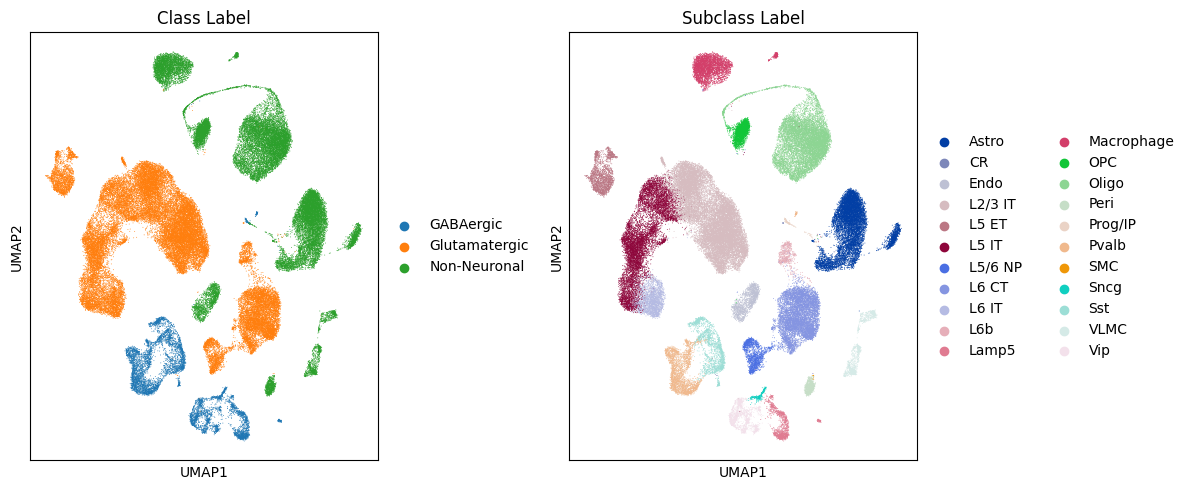

In [17]:
# Plot UMAP
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(
    adata_sc,
    color="Allen.class_label",
    ax=axes[0],
    show=False,
    title="Class Label"
)
sc.pl.umap(
    adata_sc,
    color="Allen.subclass_label",
    ax=axes[1],
    show=False,
    title="Subclass Label"
)
plt.tight_layout()
plt.show()

We can see that classes are much less specific than subclasses, implying a less detailed selection paired with a smaller computational cost (spapros traines a tree for each label).

In [18]:
print(f"Cell classes: {adata_sc.obs['Allen.class_label'].nunique()}")
print(f"Cell subclasses: {adata_sc.obs['Allen.subclass_label'].nunique()}")

Cell classes: 3
Cell subclasses: 22


An addtitional clustering is available:

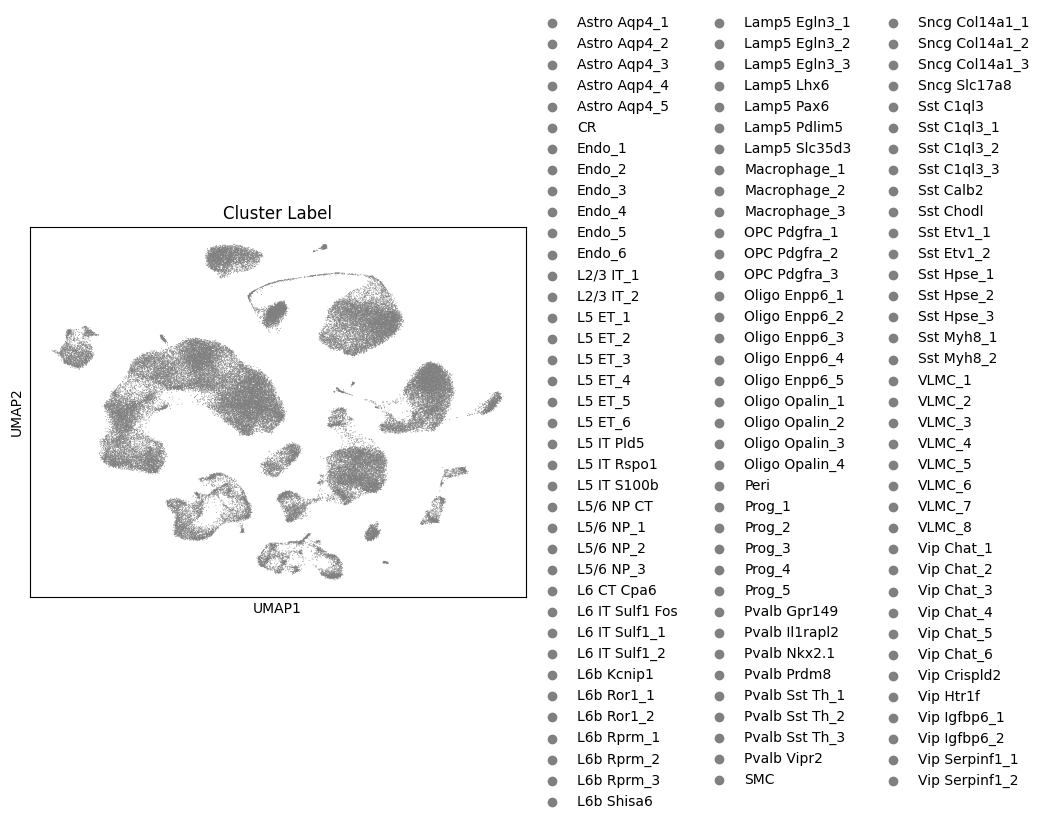

In [19]:
sc.pl.umap(adata_sc, color="Allen.cluster_label", title="Cluster Label")

In [20]:
print(f"Number of Allen cluster labels: {adata_sc.obs['Allen.cluster_label'].nunique()}")

Number of Allen cluster labels: 112


which is clearly to specific for our purposes.

### Running Spapros
To run the experiment we first we create an instance of the ProbesetSelector class. We specify the number of genes *n* and the key in adata.obs where we find the cell type annotations.

Note this default implementation is more suitable for a very limited number of probes (few dozens).

In [34]:
# Run selection
selector = sp.se.ProbesetSelector(adata_sc, n=20, celltype_key="Allen.subclass_label", verbosity=1, save_dir=None)

TypeError: ufunc 'invert' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

#### Monkey-Patching `split_train_test_sets` in Spapros

The Spapros function `split_train_test_sets` raises a `TypeError` when creating training and test splits. This happens because the function builds a boolean array (`test_obs`) and later applies `np.invert`, but pandas can sometimes coerce this array to `object` dtype during assignment to `adata.obs`. When `np.invert` is called on an `object` array, it fails. The coercion can occur depending on the structure of the data, the existing columns in `adata.obs`, or the type of cell type labels, even if they are categorical.

To avoid this issue, we applied a **monkey patch** that replaces the original function at runtime with a safe version ensuring that all boolean masks retain `bool` dtype. This guarantees that `ProbesetSelector` can split training and test sets correctly. The patch only affects the current Python session and does not modify the library source code.

In [8]:
# Ensure class labels are categoricals
adata_sc.obs['Allen.class_label'] = adata_sc.obs['Allen.class_label'].astype('category')
# adata_sc.obs['Allen.class_label'] = adata_sc.obs['Allen.class_label'].cat.remove_categories(["Low Quality"])

In [9]:
# Pre-allocate train/test set annotations as bool
adata_sc.obs["train_set"] = False
adata_sc.obs["test_set"] = False
adata_sc.obs["train_set"] = adata_sc.obs["train_set"].astype(bool)
adata_sc.obs["test_set"] = adata_sc.obs["test_set"].astype(bool)

In [10]:
# Monkey patch split function
import spapros.evaluation.evaluation as ev_internal

def patched_split_train_test_sets(adata, split=4, seed=42, verbose=True, obs_key=None):
    if not obs_key:
        return ev.split_train_test_sets(adata, split=split, seed=seed, verbose=verbose, obs_key=obs_key)
    adata.obs["train_set"] = False
    adata.obs["test_set"] = False
    for group in adata.obs[obs_key].unique():
        df = adata.obs.loc[adata.obs[obs_key] == group]
        n_obs = len(df)
        n_train = (n_obs // (split + 1)) * split
        np.random.seed(seed)
        train_idx = np.random.choice(n_obs, n_train, replace=False)
        test_obs = np.ones(n_obs, dtype=bool)    # ensure boolean
        test_obs[train_idx] = False
        train_obs = ~test_obs                   # boolean negation
        adata.obs.loc[df.index, "train_set"] = train_obs
        adata.obs.loc[df.index, "test_set"] = test_obs

ev_internal.split_train_test_sets = patched_split_train_test_sets

In [28]:
# Check overwriting
ev_internal.split_train_test_sets

<function __main__.patched_split_train_test_sets(adata, split=4, seed=42, verbose=True, obs_key=None)>

#### OBS: Missing labels
Before running the selection, one must handle NaN values from the class label column that spapros selector would place into spurious label.

To avoid including uninformative cells for the selection and prevent risky downstream modifications to the selector object (e.g. removing NAs label from the *ct_keys* attribute), cells with a missing class are completely removed from the data (in the cells selection notebook).

In [11]:
print("categories:", adata_sc.obs['Allen.class_label'].cat.categories)
print("value_counts:", adata_sc.obs['Allen.class_label'].value_counts())

categories: Index(['GABAergic', 'Glutamatergic', 'Non-Neuronal'], dtype='object')
value_counts: Allen.class_label
Glutamatergic    41205
Non-Neuronal     28687
GABAergic         7445
Name: count, dtype: int64


### Probe selection
If we are interested in determining a larger number of probe genes, e.g. $>150$ like in MERISH data, spapros suggests (readthedocs documentation on Advanced probeset selection) to run a dual selection: the idea is to run a selection first (we do not fix $n$ and we do not use PCA selected genes for that run), exclude the genes of that selection, run a second (standard) selection, and combine the results of both runs.

In our case, we limit ourselves to setting `n=None` and `n_genes_pca=0`, so that the number of probes is automatically determined.

In [12]:
# Down-cast to float32 to save space
# adata_sc.X = adata_sc.X.astype("float32").tocsr()

# Temporary write and re-read in backed mode
# adata_sc.write("adata_temp.h5ad")
# adata_sc = sc.read_h5ad("adata_temp.h5ad", backed="r")

# Run probe selection - class level
selector = sp.se.ProbesetSelector(adata=adata_sc, celltype_key='Allen.class_label', n=None, n_pca_genes=0)

C:\Users\enric\tangram\.venv\lib\site-packages\spapros\evaluation\evaluation.py:1480: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = a.obs.groupby(ct_key)["test_set"].value_counts()


The output object contains several attributes of interest:

In [13]:
# Check classes consistency
ct_key = selector.ct_key
print("ct_key:", ct_key)
print("adata.obs[ct_key].unique():", selector.adata.obs[ct_key].unique())  # check NaN column
print("spapros groups:", selector.celltypes)  # check nan group

ct_key: Allen.class_label
adata.obs[ct_key].unique(): ['Glutamatergic', 'Non-Neuronal', 'GABAergic']
Categories (3, object): ['GABAergic', 'Glutamatergic', 'Non-Neuronal']
spapros groups: ['Glutamatergic', 'Non-Neuronal', 'GABAergic']


In [33]:
# Handle NAs in the selector object (skip)
# ct_key = selector.ct_key
# selector.adata = selector.adata[selector.adata.obs[ct_key].notna()].copy()

After creating the object, we can call the ad-hoc method for probe selection:

In [14]:
# Call method
selector.select_probeset()

Output()

C:\Users\enric\tangram\.venv\lib\site-packages\spapros\evaluation\evaluation.py:2311: FutureWarning: Setting an 
item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 
'0.034891714889228966' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  tab.loc[gene, "importance_score"] = max(tmp_scores) if tmp_scores else 0

In [15]:
# Explore probeset
selector.probeset

,gene_nr,selection,rank,marker_rank,tree_rank,importance_score,pca_score,pre_selected,prior_selected,pca_selected,celltypes_DE_1vsall,celltypes_DE_specific,celltypes_DE,celltypes_marker,list_only_ct_marker,required_marker,required_list_marker
Grip1,1,True,1.0,1.0,1.0,0.935972,0,False,False,False,GABAergic,,GABAergic,GABAergic,False,True,False
Kcnip4,2,True,1.0,1.0,1.0,0.692275,0,False,False,False,Glutamatergic,,Glutamatergic,Glutamatergic,False,True,False
Apoe,3,True,1.0,1.0,1.0,0.034892,0,False,False,False,Non-Neuronal,,Non-Neuronal,Non-Neuronal,False,True,False
Galntl6,4,True,1.0,2.0,1.0,0.267609,0,False,False,False,GABAergic,,GABAergic,GABAergic,False,True,False
Homer1,5,True,1.0,2.0,1.0,0.020557,0,False,False,False,Glutamatergic,,Glutamatergic,Glutamatergic,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd4l,3996,False,NaN,NaN,NaN,NaN,0,False,False,False,,,,,False,False,False
mt-Nd4,3997,False,NaN,NaN,NaN,NaN,0,False,False,False,,,,,False,False,False
mt-Cytb,3998,False,NaN,NaN,NaN,NaN,0,False,False,False,,,,,False,False,False
CAAA01165726.1,3999,False,NaN,NaN,NaN,NaN,0,False,False,False,,,,,False,False,False


In [16]:
# Store selected genes
spapros_probes = list(selector.probeset.loc[selector.probeset['selection'] == True].index)
spapros_probes

['Grip1',
 'Kcnip4',
 'Apoe',
 'Galntl6',
 'Homer1',
 'Cst3',
 'Gad1',
 'Nyap2',
 'Dock1']

We can see that the number of selected genes with this run is extremely limited.

#### Visualization
Here we plot the mean expression in each cell type cluster with some additional information for the fselected genes: 
"
For each cell type the Spapros markers are those that build a combinatorial rule to classify the cell type. Often you find cell type specific markers, and negative markers. When selecting genes for high numbers of cell types including similar clusters the rules tend to show more sophisticated combinatorics
"

C:\Users\enric\tangram\.venv\lib\site-packages\spapros\plotting\_masked_dotplot.py:546: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  dot_ax.scatter(x, y, **kwds)


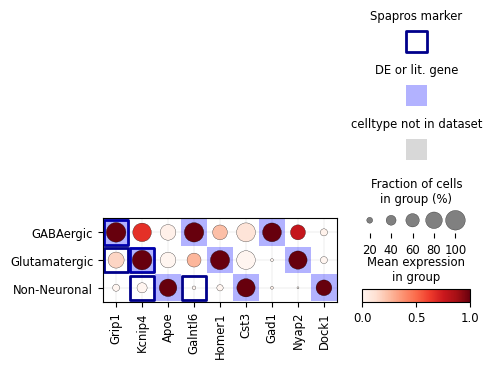

In [17]:
# Visualize selection
sp.pl.masked_dotplot(adata=adata_sc, selector=selector, ct_key=ct_key)

#### Evaluation
Spapros provides metrics to evaluate the quality of a gene panel. For evaluation, it mainly focuses on 2 metric categories: general variation recovery and cell type classification. Additionally as a 3rd category it measures gene redundancy based on correlation between gene pairs.

In [36]:
evaluator = sp.ev.ProbesetEvaluator(
    adata_sc,
    verbosity=0,
    results_dir=None,
    metrics=['forest_clfs', 'marker_corr']
)
# remove gene_corr to avoid memory blow-up (n_genes x n_genes float64 matrix)
del evaluator.metrics_params["gene_corr"]

In [ ]:
# Run evaluation and show results
evaluator.evaluate_probeset(spapros_probes, set_id="Spapros")
evaluator.summary_results

#### Store selection
Here we wish to store the probe selection results on the anndata object by first adding a boolean *adata_sc.var['spapros_probe']* field and some metrics relative to them:

In [29]:
# Store in field
adata_sc.var['spapros_probe'] = adata_sc.var.index.isin(spapros_probes)
# skip score
# adata_sc.varm['spapros_score'] = selector.probeset['importance_score']

# Spatial Data

## Data loading
Four different slices of the same tissue are available for spatial transcitomics MERFISH data, each with a slightly different number of spots:

In [5]:
#adata_st = sq.datasets.merfish()
adata_st_153 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice153_norm_wo_raw.h5ad')
adata_st_153

AnnData object with n_obs × n_vars = 7469 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [76]:
adata_st_200 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice200_norm_wo_raw.h5ad')
adata_st_200

AnnData object with n_obs × n_vars = 2155 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [80]:
adata_st_102 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice102_norm_wo_raw.h5ad')
adata_st_102

AnnData object with n_obs × n_vars = 6731 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [79]:
adata_st_40 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice40_norm_wo_raw.h5ad')
adata_st_40

AnnData object with n_obs × n_vars = 4070 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [41]:
adata_st_153.obs.head()

,sample_id,slice_id,class_label,subclass,label,instance_id,centroid_x,centroid_y,region
cell_id,,,,,,,,,
100018547319796564052034805202079258035,mouse1_sample3,mouse1_slice153,Other,Peri,Peri,100018547319796564052034805202079258035,3151.071631,-2716.287310,mouse1_slice153
100043550028304404965222542799811957446,mouse1_sample3,mouse1_slice153,Glutamatergic,L5 ET,L5_ET_4,100043550028304404965222542799811957446,4143.971004,-3689.231495,mouse1_slice153
100067545966168255385543770338365317615,mouse1_sample3,mouse1_slice153,Other,VLMC,VLMC,100067545966168255385543770338365317615,2910.051443,-860.500238,mouse1_slice153
10008519665827599241297856039670162849,mouse1_sample3,mouse1_slice153,Other,Oligo,Oligo_1,10008519665827599241297856039670162849,2929.839508,-2476.962398,mouse1_slice153
100103011697713173197099481662394607724,mouse1_sample3,mouse1_slice153,Glutamatergic,L6 IT Car3,L6_IT_Car3,100103011697713173197099481662394607724,3814.556637,-3426.169647,mouse1_slice153


In [42]:
adata_st_153.var.head()

,is_sequential,is_combinatorial
index,,
1700022I11Rik,False,True
1810046K07Rik,False,True
5031425F14Rik,False,True
5730522E02Rik,False,True
Acta2,False,True


As we can appreciate, MERFISH data has a considerably lower number of genes identified, but a variable number of observatons/voxels.

Check that all spatial datasets share the same genes:

In [43]:
adata_st_153.var.index.all() == adata_st_200.var.index.all() == adata_st_102.var.index.all() == adata_st_40.var.index.all()

np.True_

All spatial data has already been pre-processed with removal of zero-count genes:

In [49]:
all_zero_count_st = sum(np.array(adata_st_153.X.sum(axis=0)).flatten() == 0)
all_zero_count_st

np.int64(0)

For the following exploration we are going to use *adata_st_153* as it includes the largest number of spatial spots, possibly yielding the most representative insights of the data.

For Tangram, on the other hand, we might adopt a smaller alternative to lighten the computational cost of training. It is assumed that these datasets, more or less share the same spatial attributes, meaning that the analysis results are easily extendible across them.

## HVGs
Similarly to the sc data, we compute the HVGs of the spatial dataset, but this time, since the data has a considerably lower number of genes, we adopt the **'seurat'** flavour, the only one that does not require to specify the arg *n_top_genes*.

In [27]:
print(f"Min: {adata_st_153.X.min()}, " + f"Max: {adata_st_153.X.max()}") 

Min: 0.0, Max: 224.41624450683594


Counts show that data contains raw counts, but for HVGs log1p normalized counts are needed:

In [6]:
# Store raw counts
adata_st_153.raw = adata_st_153

# Normalize counts per cell
sc.pp.normalize_total(adata_st_153, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata_st_153)

In [7]:
# Find HVGs
sc.pp.highly_variable_genes(adata_st_153, flavor='seurat')

In [55]:
adata_st_153.var['highly_variable'].sum()

np.int64(31)

A total of 31 HVGs are selected with Seurat.

## Spatial DE analysis
In this section we wish to perform a spatial Differential Expression analysis of the spatial data. 

Initially, we opted for the model based algorithm avaiable with the SpatialDE python package, but due to dependencies conflict that resulted into the following error:

In [12]:
!uv pip show spatialde

Name: spatialde
Version: 1.1.1.dev112+g6dbdb559a
Location: C:\Users\enric\tangram\.venv\Lib\site-packages
Requires: anndata, gpflow, h5py, matplotlib, naivede, numpy, pandas, scipy, tensorflow, tensorflow-probability, tqdm
Required-by:


Using Python 3.10.17 environment at: C:\Users\enric\tangram\.venv


In [11]:
from SpatialDE import SpatialDE

ImportError: cannot import name 'KerasLazyLoader' from 'tensorflow.python.util.lazy_loader' (C:\Users\enric\tangram\.venv\lib\site-packages\tensorflow\python\util\lazy_loader.py)

### Spatial Correlation

Ultimately opting for an alternative approach and avoid a cascade of possible dependencies conflicts resulting from the scipy downgrade.

We use Squidpy's Graph sub-module's function to calculate a global autocorrelation statistic (Moran’s I or Geary’s C) directly on the anndata object:

In [60]:
adata_st_153.obsm['spatial'] = adata_st_153.obs[['centroid_x', 'centroid_y']]

Unfortunately, some of the spots are spatially unresolved, meaning that they miss the coordinates, thus we need to remove them:

In [34]:
np.isnan(adata_st_153.obsm["spatial"]).sum(axis=0)

centroid_x    77
centroid_y    77
dtype: int64

In [61]:
# Create a mask for rows without NaNs
valid_mask = ~np.isnan(adata_st_153.obsm["spatial"]).any(axis=1)

# Subset AnnData to only valid spots
adata_st_153 = adata_st_153[valid_mask].copy()

Now we can proceed with the correlation:

In [62]:
# Obtain spatial neighbors graph with default args
sq.gr.spatial_neighbors(adata_st_153)

 # Compute spatial correlation with default args
sq.gr.spatial_autocorr(adata_st_153, mode='moran')  # or 'geary'

In [63]:
print(f"Moran statistic min: {min(adata_st_153.uns['moranI']['I'])} and max: {max(adata_st_153.uns['moranI']['I'])}")

Moran statistic min: -0.0020802680366134767 and max: 0.22910053226777896


In [64]:
# Repeat for Geary's
sq.gr.spatial_autocorr(adata_st_153, mode='geary')
print(f"Geary statistic min: {min(adata_st_153.uns['gearyC']['C'])} and max: {max(adata_st_153.uns['gearyC']['C'])}")

Geary statistic min: 0.7679934364292391 and max: 1.0063838785505705


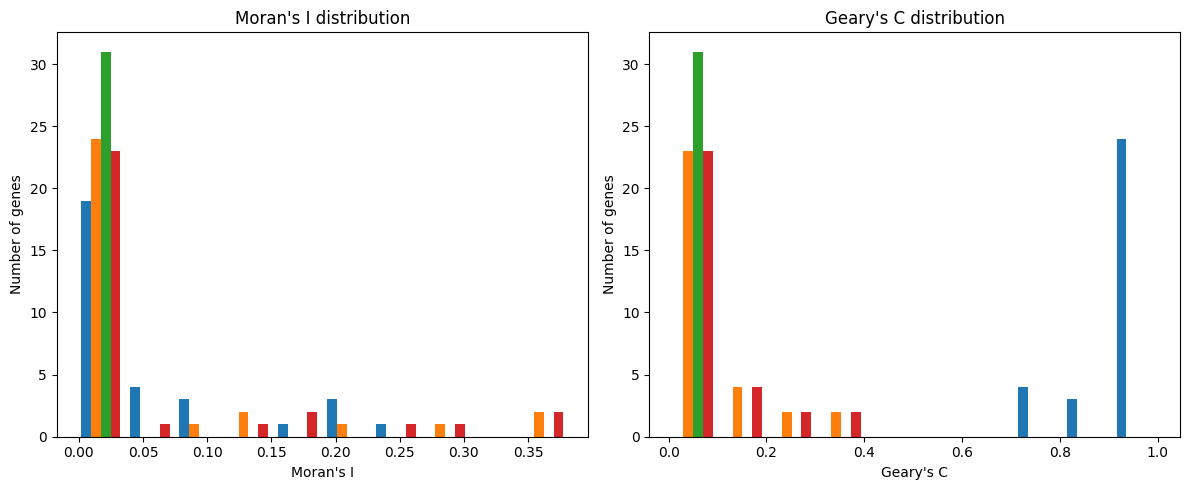

In [65]:
# Side by side distribution plot

# Extract values
moran_values = adata_st_153.uns["moranI"]
geary_values = adata_st_153.uns["gearyC"]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(moran_values.dropna(), bins=10)
axes[0].set_title("Moran's I distribution")
axes[0].set_xlabel("Moran's I")
axes[0].set_ylabel("Number of genes")

axes[1].hist(geary_values.dropna(), bins=10)
axes[1].set_title("Geary's C distribution")
axes[1].set_xlabel("Geary's C")
axes[1].set_ylabel("Number of genes")

plt.tight_layout()
plt.show()


From this statistics we can later identify genes that are spatially correlated by applying a threshold over the values, even though it is not possible to extract further information on the specific spatial pattern that they exhibit (SpatialDE allows to identify spatial structures).

Note that the final anndata object has lesser observations than the original one.

**Observation: Effect of Normalization on Spatial Autocorrelation.**

Spatial autocorrelation metrics, such as Moran's I and Geary's C, quantify whether gene expression levels are similar across neighboring spatial spots. These metrics are sensitive to the scale and distribution of the input data:

- **Raw counts**: High-count genes or spots with large library sizes can dominate the statistics, potentially inflating Moran's I and masking true spatial patterns.
- **Normalized counts**: Adjusting for library size removes technical biases, allowing the spatial autocorrelation to reflect genuine biological variation.
- **Log-transformation**: Stabilizes variance, reducing the influence of very highly expressed genes.

**Best practice**: Compute Moran's I and Geary's C on log-normalized expression data to ensure that spatial patterns are biologically meaningful and comparable across genes or datasets.


## Sparsity
For spatial data, we focus direclty on the gene specific sparsity level:

In [66]:
# Compute the sparsity of each gene (column) in the count matrix
sparsity_st = np.mean(adata_st_153.X == 0, axis=0)

# Add sparsity information to the 'var' DataFrame
adata_st_153.var['sparsity'] = sparsity_st

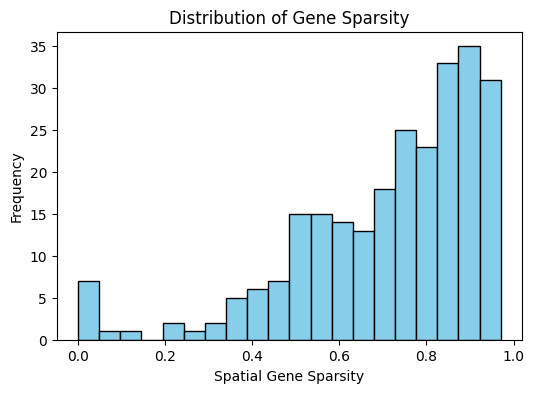

In [67]:
# Histogram
plt.figure(figsize=(6,4))
plt.hist(adata_st_153.var['sparsity'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Spatial Gene Sparsity')
plt.ylabel('Frequency')
plt.title('Distribution of Gene Sparsity')
plt.show()

# Training Genes (Intersection Subset)

We extract the intersection of genes manually with this code:

In [15]:
overlap_genes = list(set(adata_sc.var.index) & set(adata_st_153.var.index))
print('Number of intersecting genes:', len(overlap_genes))

Number of intersecting genes: 253


To integrate them directly in the anndata objects we can run the pre-exisitng function in Tangram mapping utilities: pp_adatas()

In [23]:
tg.pp_adatas(adata_sc, adata_st_153)

INFO:root:252 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:252 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


which creates the following list in the unstrucutred section of both annotated datasets:

In [16]:
# Add to sc data
adata_sc.uns['training_genes'] = overlap_genes

In [24]:
print("Intersection check:", adata_sc.uns['training_genes'] == adata_st_153.uns['training_genes'])

Intersection check: True


The mismatch in the number of overlapping genes might be due to the presence of intersection genes with all-zero counts that are removed in tg.pp_adatas() (check before running it).

From here on we refer to the overlap set present in the anndata objects, which is fully pre-processed.

#### Save pp spatial slice 153

In [86]:
# Store training genes and write file
adata_st_153.uns['training_genes'] = overlap_genes
adata_st_153.write_h5ad(filename='H:/Il mio Drive/data_tangram/slice153_pp.h5ad')

## Crop SC data
We decide to save a new anndata file for the single cell data reducing the columns/variables to only the set of genes intersecting with spatial data.

This dataset contains HVGs and Spapros annotation, UMAP and PCA, a neighborhood graph (sparsity annotation will be added on the cropped data later):

In [44]:
adata_sc_crop = adata_sc[:,overlap_genes].copy()
adata_sc_crop

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [45]:
adata_sc_crop.write_h5ad(filename='H:/Il mio Drive/data_tangram/counts100k_filt_pp_train_genes.h5ad')

In [13]:
# Read from here for later use
adata_sc = sc.read_h5ad(filename='H:/Il mio Drive/data_tangram/counts100k_filt_pp_train_genes.h5ad')
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe'
    uns: 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## Genes intersection analysis
Masks are created on the training genes for both datasets. The purpose is to asses how certain qualities characterize the two datasets genes.

### Spapros probes
Only one out of the 9 probes is contained in the spatial data:

In [43]:
# Check probes
for probe in spapros_probes:
    print(probe in overlap_genes)

False

False

False

False

False

False

True

False

False

This suggests that for a more fruitful implementation of Spapros a different experiment is required. An option could be to set the initial *probes_set* to the overlapping genes.

### Sparsity level
We first asses the sparsity level that affects the training genes in both datasets. This could give crutial insight on the numerical performance of the aligment.

#### SC data

In [17]:
# Get training genes indices in sc data
train_gene_indices_sc = [adata_sc.var_names.get_loc(g) for g in adata_sc.uns['training_genes']]
len(train_gene_indices_sc)

253

In [27]:
# Compute fraction of 0 expression cells for each gene
sparsity_sc = ((adata_sc.X[:, train_gene_indices_sc] == 0).sum(axis=0)/adata_sc.X.shape[0]) # returns numpy.matrix
sparsity_sc = np.array(sparsity_sc).reshape((253,))  # turn into numpy.array for reshaping

In [20]:
# Make pandas series with gene names as index
sparsity_sc_series = pd.Series(data=sparsity_sc, index=adata_sc.var_names[train_gene_indices_sc])

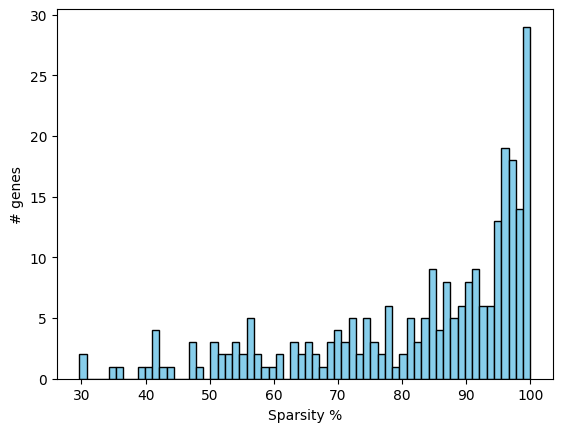

In [21]:
plt.hist(sparsity_sc*100, bins=62, color='skyblue', edgecolor='black')
plt.xlabel('Sparsity %')
plt.ylabel('# genes')
plt.show()

From the histogram of sparsity level across genes we can define a proper threshold:

In [184]:
sparsity_threshold = 0.90
mask_sc = (sparsity_sc > sparsity_threshold)
mask_sc.sum()

np.int64(125)

In [28]:
# Compute the sparsity of each gene (column) in the count matrix
# sparsity_sc = np.mean(adata_sc.X == 0, axis=0)

# Add sparsity information to the 'var' DataFrame
adata_sc.var['sparsity'] = sparsity_sc
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe', 'sparsity'
    uns: 'hvg', 'neighbors', 'pca', 'umap', 'training_genes'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [30]:
# Save with sparsity col added
adata_sc.write_h5ad(filename='H:/Il mio Drive/data_tangram/counts100k_filt_pp_train_genes.h5ad')

#### Spatial data

In [27]:
# Compute fraction of 0 expression cells for each gene
train_gene_indices_st = [adata_st_153.var_names.get_loc(g) for g in adata_st_153.uns['training_genes']]
sparsity_st = (adata_st_153.X[:, train_gene_indices_st] == 0).sum(axis=0)/adata_st_153.X.shape[0]

In [54]:
# Make pandas series with gene names as index
sparsity_st_series = pd.Series(data=sparsity_st, index=adata_st_153.var_names[train_gene_indices_st])

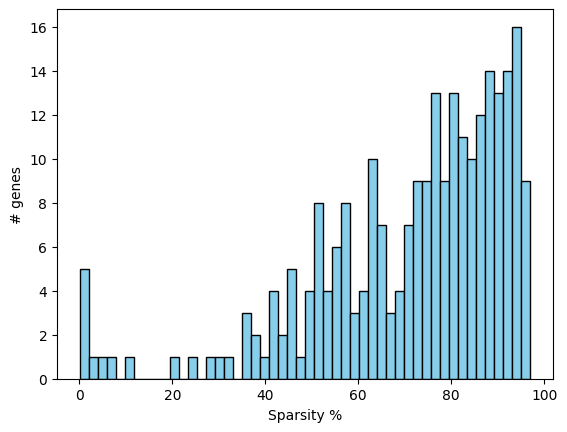

In [16]:
plt.hist(sparsity_st*100, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Sparsity %')
plt.ylabel('# genes')
plt.show()

For spatial data the situation is slighly better:

In [48]:
mask_st = (sparsity_st > sparsity_threshold)
mask_st.sum()

NameError: name 'sparsity_threshold' is not defined

With the following lines, we can quickly appreciate the entity of the intersection by means of a traffic-light plot:

*NOTE*: the sparsity signal is continuous and determines the color intensity/brightness.

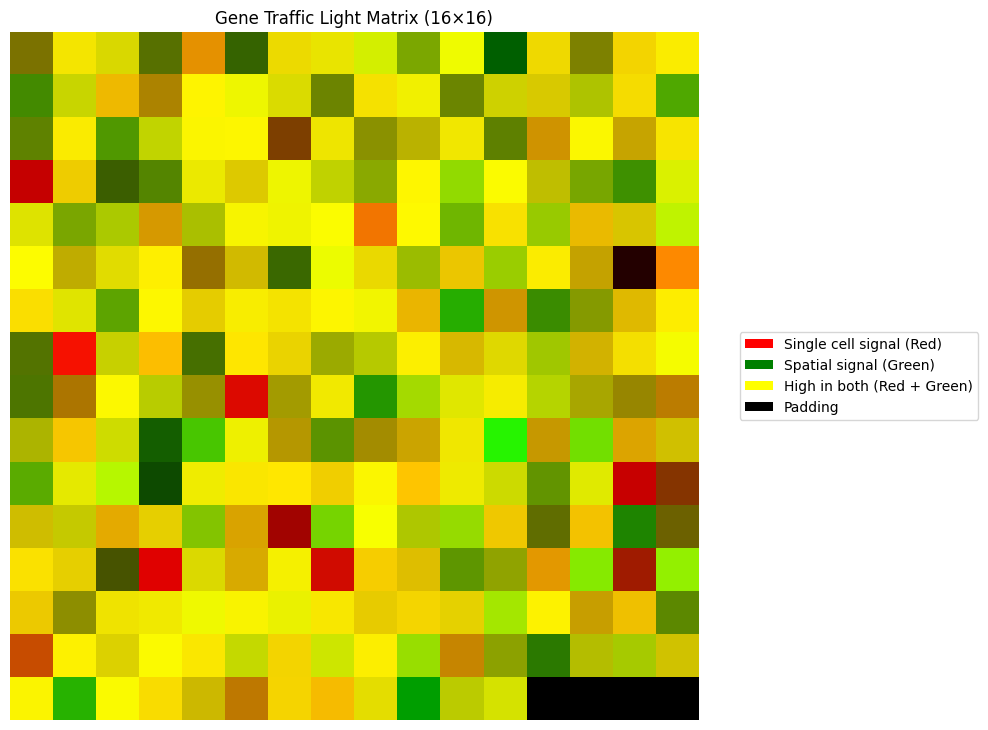

In [59]:
tg.traffic_light_plot(adata_sc.uns['training_genes'], sparsity_sc_series, sparsity_st_series)

### Expression levels
Here, instead, we try to gain some biological insight into the training genes set by observing whether or not they exhibit either high variability in the single cell data or strong spatial correlation:

In [191]:
adata_sc.var

,gene_ids,feature_types,highly_variable,highly_variable_rank,means,variances,variances_norm,n_cells
xkr4,0,Gene Expression,False,NaN,2.405056,2.982341,1.251456,70569
gm1992,1,Gene Expression,False,NaN,0.485666,0.542413,0.966567,37401
gm37381,2,Gene Expression,False,NaN,0.003646,0.003860,0.847213,443
rp1,3,Gene Expression,False,NaN,0.022113,0.025509,0.863815,2488
sox17,4,Gene Expression,True,451.0,0.023107,0.057735,1.868476,1053
...,...,...,...,...,...,...,...,...
ac168977.1,31048,Gene Expression,False,NaN,0.000815,0.000999,1.012864,84
ac149090.1,31049,Gene Expression,False,NaN,1.871865,1.652784,0.881002,74071
caaa01118383.1,31050,Gene Expression,False,NaN,0.134559,0.183607,1.053810,12034
vmn2r122,31051,Gene Expression,False,NaN,0.000008,0.000006,1.000021,1


In [35]:
# Create sc mask
# Set mask = 1 for HVGs
mask_sc = adata_sc.var.loc[adata_sc.uns['training_genes'], 'highly_variable']  # on training genes only
print(f"Number of HVGs={mask_sc.sum()} over number of training genes={mask_sc.shape[0]}")

Number of HVGs=100 over number of training genes=252


In [47]:
mask_sc.index  # already contains gene names

Index(['cnr1', 'cplx3', 'vwc2', 'camk2d', 'sertm1', 'shisa9', 'nr2f2', 'rerg',
       'l3mbtl4', 'olfm3',
       ...
       'hpse', 'lsp1', 'fezf2', 'gad1', 'cldn5', 'calb2', 'col23a1', 'rfx3',
       'tmem163', 'opalin'],
      dtype='object', length=252)

For spatial data correlation we just use the continuous moran I statisc:

In [44]:
adata_st_153.var_names

Index(['1700022i11rik', '1810046k07rik', '5031425f14rik', '5730522e02rik',
       'acta2', 'adam2', 'adamts2', 'adamts4', 'adra1b', 'alk',
       ...
       'gad2', 'tac2', 'lamp5', 'cnr1', 'pvalb', 'sst', 'rab3b', 'slc17a7',
       'penk', 'gad1'],
      dtype='object', length=254)

In [42]:
adata_st_153.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
Rorb,0.507490,0.000000,0.000041,0.000000
Cux2,0.487229,0.000000,0.000041,0.000000
Lamp5,0.455303,0.000000,0.000041,0.000000
Calb1,0.440135,0.000000,0.000041,0.000000
Bcl11b,0.431898,0.000000,0.000041,0.000000
...,...,...,...,...
5031425F14Rik,-0.002627,0.349396,0.000041,0.360759
Cdcp1,-0.004777,0.235531,0.000041,0.244183
1700022I11Rik,-0.004966,0.226613,0.000041,0.236872
5730522E02Rik,-0.005272,0.212558,0.000041,0.224957


In [77]:
# Use lambda function to convert gene names to lower case
adata_st_153.uns['moranI'].index = adata_st_153.uns['moranI'].index.map(lambda x: str(x).lower())
adata_st_153.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
rorb,0.507490,0.000000,0.000041,0.000000
cux2,0.487229,0.000000,0.000041,0.000000
lamp5,0.455303,0.000000,0.000041,0.000000
calb1,0.440135,0.000000,0.000041,0.000000
bcl11b,0.431898,0.000000,0.000041,0.000000
...,...,...,...,...
5031425f14rik,-0.002627,0.349396,0.000041,0.360759
cdcp1,-0.004777,0.235531,0.000041,0.244183
1700022i11rik,-0.004966,0.226613,0.000041,0.236872
5730522e02rik,-0.005272,0.212558,0.000041,0.224957


In [78]:
# Create st mask
mask_st = adata_st_153.uns['moranI'].loc[adata_st_153.uns['training_genes'],'I']
mask_st.shape[0]

252

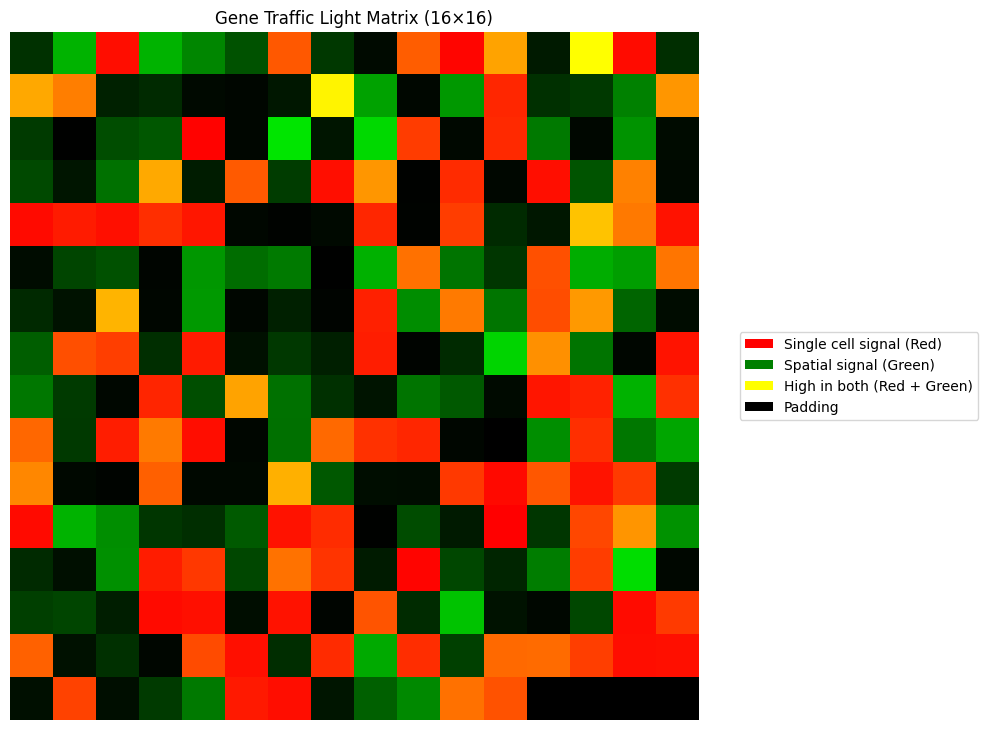

In [79]:
tg.traffic_light_plot(adata_sc.uns['training_genes'], mask_sc, mask_st)

Fully red boxes are scrna HVGs, while yellow boxes are also spatially correlated (remind that this plot does not resemble any spatial structure) and green boxes are only correlated spatially and are not HVGs

Black spots refer to non HVGs that also exhibit low spatial correlation. We can check that numerous spots have a low morans' statistic.

In [89]:
sum(adata_st_153.uns['moranI']['I']<0.01)

33

# Crop SC data
We decide to save a new anndata file for the single cell data reducing the columns/variables to only the set of genes intersecting with spatial data:

In [71]:
adata_sc_crop = adata_sc[:,overlap_genes].copy()
adata_sc_crop

AnnData object with n_obs × n_vars = 100000 × 252
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'training_genes', 'overlap_genes'

In [82]:
adata_sc_crop.write_h5ad(filename='H:/Il mio Drive/data_tangram/counts100k_norm_wo_raw_train_genes.h5ad')

# PP all spatial
Here we repeat the pre-processing steps on all spatial datasets.

In [81]:
# Store raw counts
adata_st_200.raw = adata_st_200

# Normalize counts per cell
sc.pp.normalize_total(adata_st_200, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata_st_200)

# Find HVGs
sc.pp.highly_variable_genes(adata_st_200, flavor='seurat')

# Create spatial field
adata_st_200.obsm['spatial'] = adata_st_200.obs[['centroid_x', 'centroid_y']]

# Create a mask for rows without NaNs
valid_mask = ~np.isnan(adata_st_200.obsm["spatial"]).any(axis=1)

# Subset AnnData to only valid spots
adata_st_200 = adata_st_200[valid_mask].copy()

# Obtain spatial neighbors graph with default args
sq.gr.spatial_neighbors(adata_st_200)

# Compute spatial correlation with default args
sq.gr.spatial_autocorr(adata_st_200, mode='moran')  # or 'geary'
# Repeat for Geary's
sq.gr.spatial_autocorr(adata_st_200, mode='geary')

# Compute the sparsity of each gene (column) in the count matrix
sparsity_st = np.mean(adata_st_200.X == 0, axis=0)

# Add sparsity information to the 'var' DataFrame
adata_st_200.var['sparsity'] = sparsity_st

# Add overlap genes field
adata_st_200.uns['training_genes'] = overlap_genes

# Store
adata_st_200.write_h5ad(filename='H:/Il mio Drive/data_tangram/slice200_pp.h5ad')

In [82]:
# Store raw counts
adata_st_102.raw = adata_st_102

# Normalize counts per cell
sc.pp.normalize_total(adata_st_102, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata_st_102)

# Find HVGs
sc.pp.highly_variable_genes(adata_st_102, flavor='seurat')

# Create spatial field
adata_st_102.obsm['spatial'] = adata_st_102.obs[['centroid_x', 'centroid_y']]

# Create a mask for rows without NaNs
valid_mask = ~np.isnan(adata_st_102.obsm["spatial"]).any(axis=1)

# Subset AnnData to only valid spots
adata_st_102 = adata_st_102[valid_mask].copy()

# Obtain spatial neighbors graph with default args
sq.gr.spatial_neighbors(adata_st_102)

# Compute spatial correlation with default args
sq.gr.spatial_autocorr(adata_st_102, mode='moran')  # or 'geary'
# Repeat for Geary's
sq.gr.spatial_autocorr(adata_st_102, mode='geary')

# Compute the sparsity of each gene (column) in the count matrix
sparsity_st = np.mean(adata_st_102.X == 0, axis=0)

# Add sparsity information to the 'var' DataFrame
adata_st_102.var['sparsity'] = sparsity_st

# Add overlap genes field
adata_st_102.uns['training_genes'] = overlap_genes

# Store
adata_st_102.write_h5ad(filename='H:/Il mio Drive/data_tangram/slice102_pp.h5ad')


In [84]:
# Store raw counts
adata_st_40.raw = adata_st_40

# Normalize counts per cell
sc.pp.normalize_total(adata_st_40, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata_st_40)

# Find HVGs
sc.pp.highly_variable_genes(adata_st_40, flavor='seurat')

# Create spatial field
adata_st_40.obsm['spatial'] = adata_st_40.obs[['centroid_x', 'centroid_y']]

# Create a mask for rows without NaNs
valid_mask = ~np.isnan(adata_st_40.obsm["spatial"]).any(axis=1)

# Subset AnnData to only valid spots
adata_st_40 = adata_st_40[valid_mask].copy()

# Obtain spatial neighbors graph with default args
sq.gr.spatial_neighbors(adata_st_40)

# Compute spatial correlation with default args
sq.gr.spatial_autocorr(adata_st_40, mode='moran')  # or 'geary'
# Repeat for Geary's
sq.gr.spatial_autocorr(adata_st_40, mode='geary')

# Compute the sparsity of each gene (column) in the count matrix
sparsity_st = np.mean(adata_st_40.X == 0, axis=0)

# Add sparsity information to the 'var' DataFrame
adata_st_40.var['sparsity'] = sparsity_st

# Add overlap genes field
adata_st_40.uns['training_genes'] = overlap_genes

# Store
adata_st_40.write_h5ad(filename='H:/Il mio Drive/data_tangram/slice40_pp.h5ad')